In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.utils import Utils
from stericheight.load_meop import MEOP
from region import Region
from functions import Functions

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
import xesmf as xe
import glob
import datetime

refz=1000


In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
full_extent = [138, 150,-68,-64]
expanded_extent = [132, 156, -68, -62]

elevation = elevation_.sel(latitude = slice(expanded_extent[2], expanded_extent[3]), longitude = slice(expanded_extent[0],expanded_extent[1]))


In [6]:
# GET COLOURS
cdict = pickle.load(open('cdict.pkl','rb'))


In [7]:
dotds = DOT(ver='egm').ds.rename({'ug':'u10','vg':'v10'})
lwe_ds = GRACE(from_file=True).ds

dot = fns.crop_to_extent(dotds.dot,expanded_extent)
lwe = fns.crop_to_extent(lwe_ds.lwe_thickness,expanded_extent)

sha_ds_sla = StericHeight(ssh_ref='DOT',
                          ssh=dot,
                          msl=None,
                          lwe=lwe,
                          ).get_sha()

sha = sha_ds_sla.sha

sha = sha.where(sha < 20,np.nan)

In [9]:
#sha_ds_sla['sha'] = sha
sha_ds_sla.to_netcdf('stericheight_2002-2024.nc')

In [8]:
# compute spatial averages on the shelf
sha_ds_sla['elevation'] = elevation.interp(latitude=sha_ds_sla.latitude,longitude=sha_ds_sla.longitude)

In [9]:


# filter out craxy values
ulim=sha_ds_sla.sha.quantile(0.99)
blim=sha_ds_sla.sha.quantile(0.01)
sha_ds_sla['sha'] = sha_ds_sla.sha.where((sha_ds_sla.sha < ulim) & (sha_ds_sla.sha > blim), np.nan)

In [10]:
shelf_sha = sha_ds_sla.sha.where(sha_ds_sla.elevation > -1000,drop=True)
shelf_mass = sha_ds_sla.eha.where(sha_ds_sla.elevation > -1000,drop=True)

offshelf_sha = sha_ds_sla.sha.where(sha_ds_sla.elevation < -1000,drop=True)
offshelf_mass = sha_ds_sla.eha.where(sha_ds_sla.elevation < -1000,drop=True)

In [11]:
shelf_sha_tmean = shelf_sha.mean(['latitude','longitude'])
shelf_mass_tmean = shelf_mass.mean(['latitude','longitude'])

offshelf_sha_tmean = offshelf_sha.mean(['latitude','longitude'])
offshelf_mass_tmean = offshelf_mass.mean(['latitude','longitude'])

In [12]:
# assign colours for easy plotting
colors = {'SHA': 'palevioletred',
          'MASS': 'dodgerblue'}


In [13]:

month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
month_values = xr.DataArray(np.arange(1,13),coords={'month':np.arange(1,13)})

def plotvar(ax,da,label,ls='-',roll=False):
    da_ = da.rolling({'time':3}).mean() if roll else da
    ax.plot(da_.time,da_,label=label,c=colors[label],ls=ls)

def plotcli(ax,da,label,ls='-'):
    ax.plot(month_values,da,label=label,c=colors[label],ls=ls)
    ax.set_xticks(np.arange(1,13),labels=month_labels)

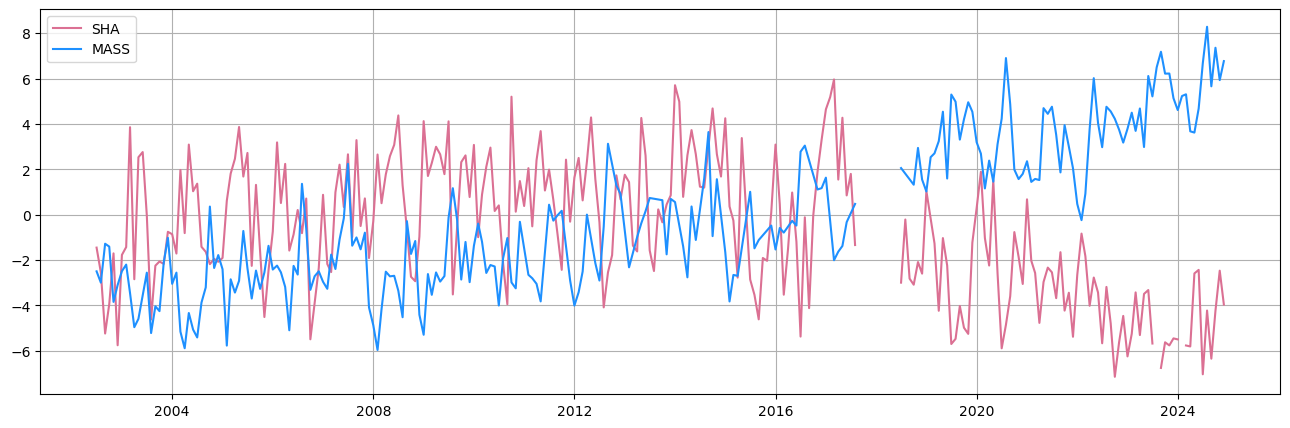

In [14]:
fig, ax = plt.subplots(figsize=(16,5))
plotvar(ax,shelf_sha_tmean,'SHA')
plotvar(ax,shelf_mass_tmean,'MASS')

ax.legend()
ax.grid()

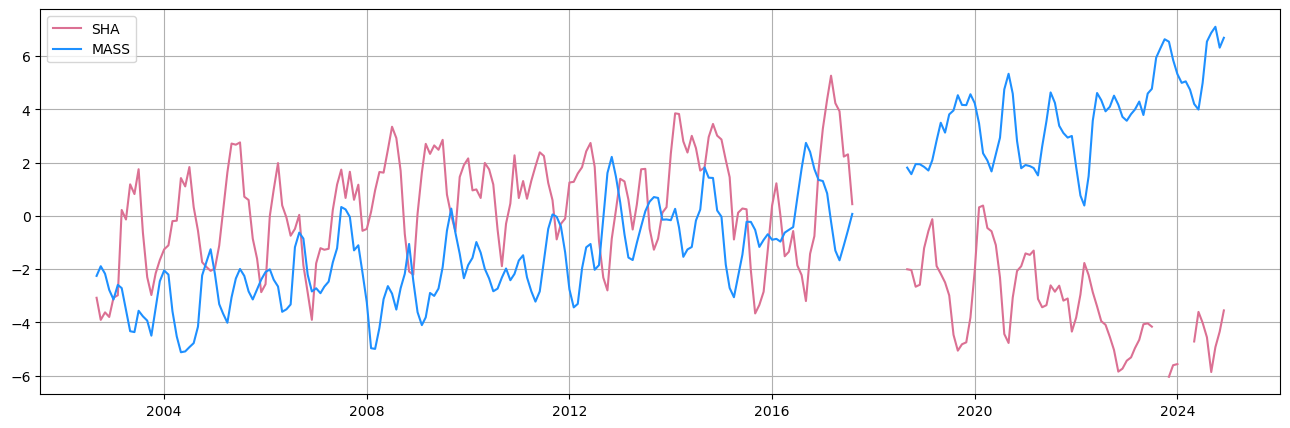

In [15]:
fig, ax = plt.subplots(figsize=(16,5))
plotvar(ax,shelf_sha_tmean,'SHA',roll=True)
plotvar(ax,shelf_mass_tmean,'MASS',roll=True)
ax.legend()
ax.grid()

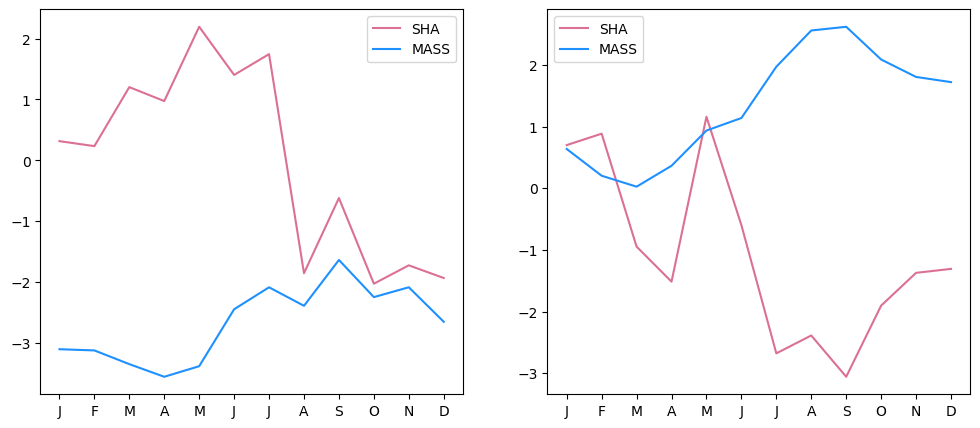

In [16]:
sha_pre2010 = shelf_sha_tmean.sel(time=slice(shelf_sha_tmean.time[0],pd.Timestamp(2010,2,10)))
lwe_pre2010 = shelf_mass_tmean.sel(time=slice(shelf_mass_tmean.time[0],pd.Timestamp(2010,2,10)))

sha_pos2010 = shelf_sha_tmean.sel(time=slice(pd.Timestamp(2010,3,1),shelf_sha_tmean.time[-1]))
lwe_pos2010 = shelf_mass_tmean.sel(time=slice(pd.Timestamp(2010,3,1),shelf_mass_tmean.time[-1]))

fig,ax = plt.subplots(1,2,figsize=(12,5))
plotcli(ax[0],sha_pre2010.groupby('time.month').mean(),'SHA')
plotcli(ax[0],lwe_pre2010.groupby('time.month').mean(), 'MASS')
plotcli(ax[1],sha_pos2010.groupby('time.month').mean(),'SHA')
plotcli(ax[1],lwe_pos2010.groupby('time.month').mean(), 'MASS')
[ax.legend() for ax in ax]
# plotcli(ax[0],sha_pre2010.groupby('time.month') - sha_pre2010.groupby('time.month').mean(),'SHA')
# plotcli(ax[0],lwe_pre2010.groupby('time.month') - lwe_pre2010.groupby('time.month').mean(), 'MASS')
# plotcli(ax[1],sha_pos2010.groupby('time.month') - sha_pos2010.groupby('time.month').mean(),'SHA')
# plotcli(ax[1],lwe_pos2010.groupby('time.month') - lwe_pos2010.groupby('time.month').mean(), 'MASS')

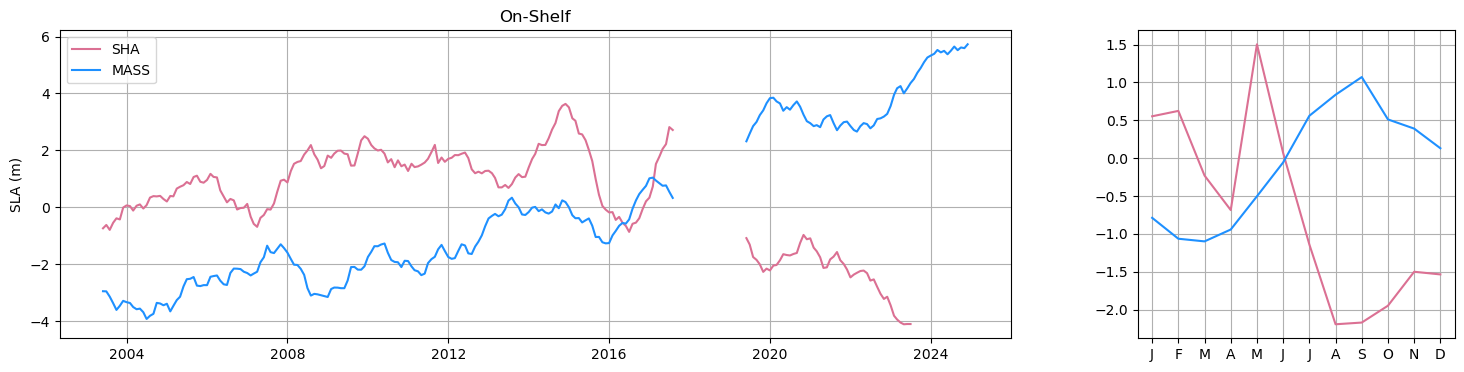

In [17]:
shelf_sha_clim = shelf_sha_tmean.groupby('time.month').mean()
shelf_mass_clim = shelf_mass_tmean.groupby('time.month').mean()


fig, axs = plt.subplots(1,2,figsize=(18,4),width_ratios=[3,1])
ax=axs[0]
plotvar(ax,(shelf_sha_tmean.groupby('time.month') - shelf_sha_clim).rolling({'time':12}).mean(),label='SHA')
plotvar(ax,(shelf_mass_tmean.groupby('time.month') - shelf_mass_clim).rolling({'time':12}).mean(),label='MASS')

ax.legend()
ax.grid()
ax.set_ylabel('SLA (m)')
ax.set_title('On-Shelf')

ax=axs[1]
plotcli(ax,shelf_sha_clim,label='SHA')
plotcli(ax,shelf_mass_clim,label='MASS')

ax.grid()

In [18]:
peak1 = pd.Timestamp(2014,12,1)
trgh1 = pd.Timestamp(2016,7,1)
peak2 = pd.Timestamp(2017,8,1)

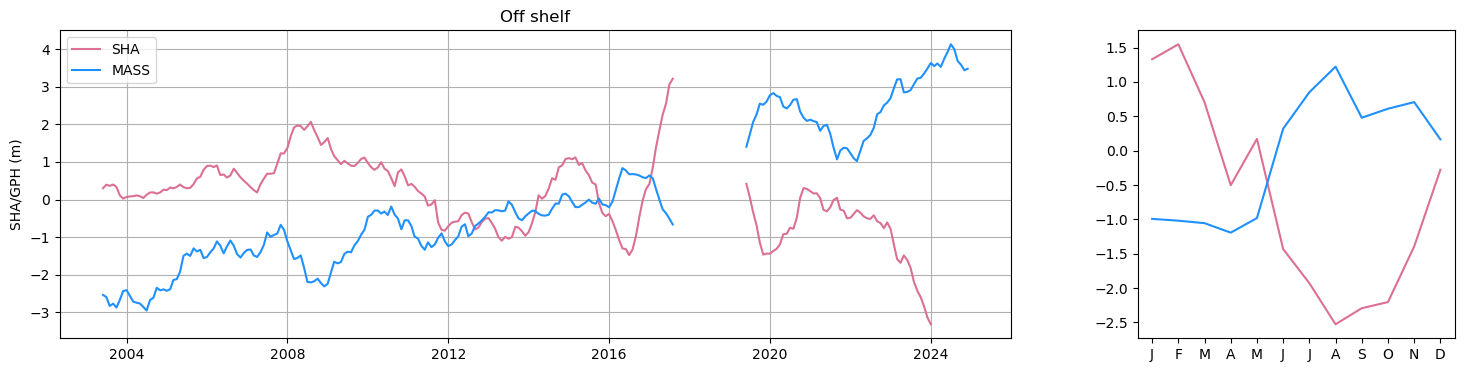

In [19]:
offshelf_sha_clim = offshelf_sha_tmean.groupby('time.month').mean()
offshelf_mass_clim = offshelf_mass_tmean.groupby('time.month').mean()


fig, axs = plt.subplots(1,2,figsize=(18,4),width_ratios=[3,1])
ax=axs[0]
plotvar(ax,(offshelf_sha_tmean.groupby('time.month') - offshelf_sha_clim).rolling({'time':12}).mean(),label='SHA')
plotvar(ax,(offshelf_mass_tmean.groupby('time.month') - offshelf_mass_clim).rolling({'time':12}).mean(),label='MASS')

ax.legend()
ax.grid()
ax.set_ylabel('SHA/GPH (m)')
ax.set_title('Off shelf')

ax=axs[1]
plotcli(ax,offshelf_sha_clim,label='SHA')
plotcli(ax,offshelf_mass_clim,label='MASS')


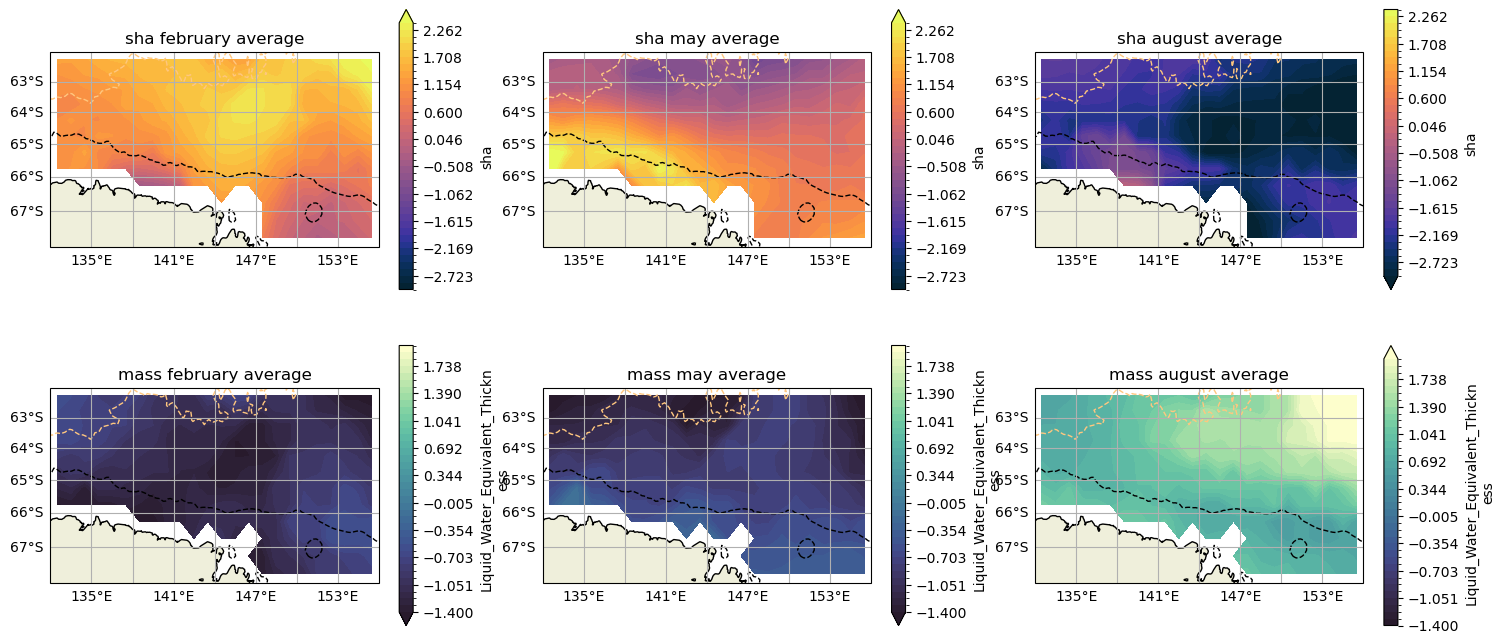

In [20]:
fig,axs2 = plt.subplots(2,3,figsize=(18,8),subplot_kw={'projection':ccrs.Mercator()})

clis = sha_ds_sla.sha.groupby('time.month').mean()
clim = sha_ds_sla.eha.groupby('time.month').mean()

axs=axs2[0]
fns.plotc(ax=axs[0],da=clis.sel(month=2),title='sha february average',extent=expanded_extent,cmap=cmocean.cm.thermal,vmin=-3,vmax=2.4)
fns.plotc(ax=axs[1],da=clis.sel(month=5),title='sha may average',extent=expanded_extent,cmap=cmocean.cm.thermal,vmin=-3,vmax=2.4)
fns.plotc(ax=axs[2],da=clis.sel(month=8),title='sha august average',extent=expanded_extent,cmap=cmocean.cm.thermal,vmin=-3,vmax=2.4)

axs=axs2[1]
fns.plotc(ax=axs[0],da=clim.sel(month=2),title='mass february average',extent=expanded_extent,cmap=cmocean.cm.deep_r,vmin=-1.4,vmax=2)
fns.plotc(ax=axs[1],da=clim.sel(month=5),title='mass may average',extent=expanded_extent,cmap=cmocean.cm.deep_r,vmin=-1.4,vmax=2)
fns.plotc(ax=axs[2],da=clim.sel(month=8),title='mass august average',extent=expanded_extent,cmap=cmocean.cm.deep_r,vmin=-1.4,vmax=2)

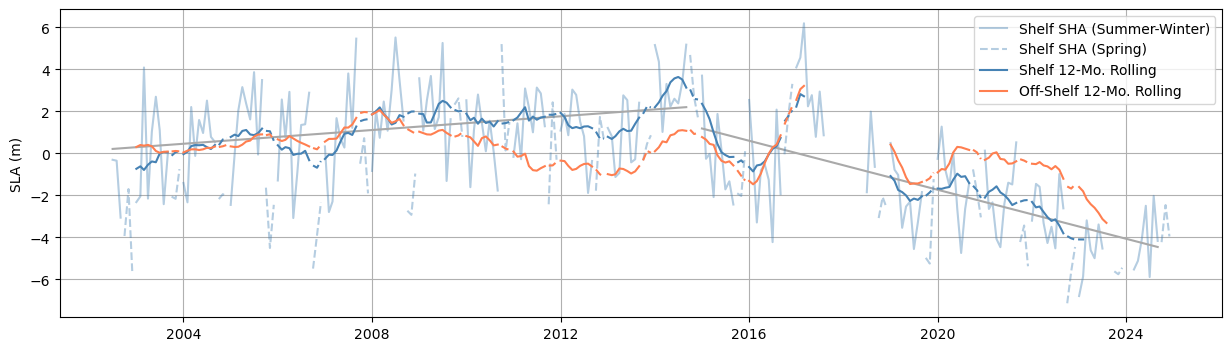

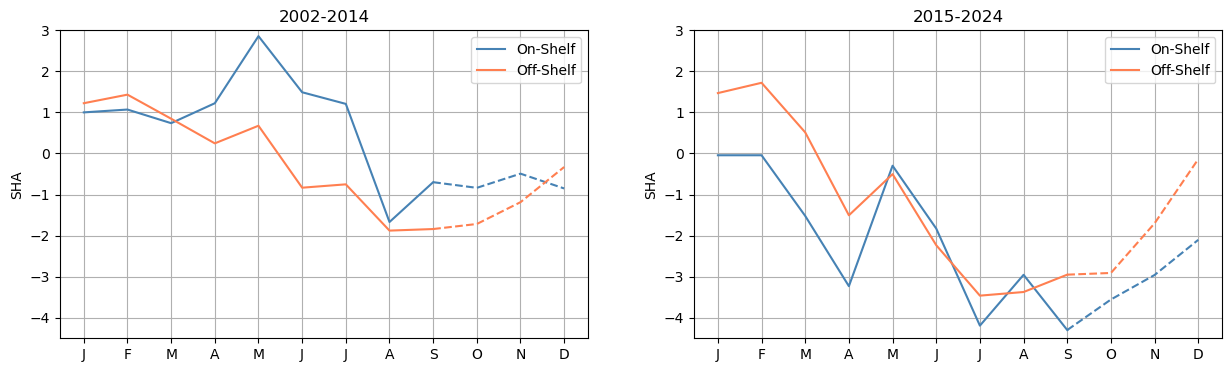

In [28]:
shelf_sha_clim = shelf_sha_tmean.groupby('time.month').mean()
offshelf_sha_clim = offshelf_sha_tmean.groupby('time.month').mean()

cshelf = 'steelblue'

months = shelf_sha_tmean.time.dt.month
asw = months < 10

fig, ax = plt.subplots(figsize=(15,4))

# first do autumn, summer and winter
da_ = (shelf_sha_tmean.groupby('time.month') - shelf_sha_clim).where(asw,np.nan)
ax.plot(da_.time,da_,label='Shelf SHA (Summer-Winter)',c=cshelf,alpha=0.4)

da_ = (shelf_sha_tmean.groupby('time.month') - shelf_sha_clim).where(asw,drop=True)
da_pre = da_.sel(time=slice(shelf_sha.time[0],pd.Timestamp(2014,12,1)))
da_pos = da_.sel(time=slice(pd.Timestamp(2014,12,1),da_.time[-1]))
fit_pre = utls.get_fit(da_pre,'time',1)
fit_pos = utls.get_fit(da_pos,'time',1).interpolate_na('time')
ax.plot(fit_pre.time,fit_pre,c='darkgrey',ls='-')
ax.plot(fit_pos.time,fit_pos,c='darkgrey',ls='-')

da_ = shelf_sha_tmean.where(~asw,np.nan)
ax.plot(da_.time,da_,label='Shelf SHA (Spring)',c=cshelf,alpha=0.4,ls='--')

da_roll = (shelf_sha_tmean.groupby('time.month') - shelf_sha_clim).rolling({'time':12},center=True).mean()
da_roll_asw = da_roll.where(asw,np.nan)
ax.plot(da_roll_asw.time,da_roll_asw,label='Shelf 12-Mo. Rolling',c=cshelf)
da_roll_s = da_roll.where(~asw,np.nan)
ax.plot(da_roll_s.time,da_roll_s,c=cshelf,ls='--')

da_roll = (offshelf_sha_tmean.groupby('time.month') - offshelf_sha_clim).rolling({'time':12},center=True).mean()
da_roll_asw = da_roll.where(asw,np.nan)
ax.plot(da_roll_asw.time,da_roll_asw,label='Off-Shelf 12-Mo. Rolling',c='coral')
da_roll_s = da_roll.where(~asw,np.nan)
ax.plot(da_roll_s.time,da_roll_s,c='coral',ls='--')

ax.legend()
ax.grid()
ax.set_ylabel('SLA (m)')

# ax=axs[1]
# asw=shelf_sha_clim.month < 10
# da_ = shelf_sha_clim.where(asw,np.nan)
# ax.plot(month_values,da_,c=cshelf)
# da_ = shelf_sha_clim.where(~asw,np.nan)
# ax.plot(month_values,da_,c=cshelf,ls='--')

# da_ = offshelf_sha_clim.where(asw,np.nan)
# ax.plot(month_values,da_,c='coral')
# da_ = shelf_sha_clim.where(~asw,np.nan)
# ax.plot(month_values,da_,c='coral',ls='--')

# ax.set_xticks(np.arange(1,13),labels=month_labels)
# ax.grid()
# plt.tight_layout()
fig, axs = plt.subplots(1,2,figsize=(15,4))

da_pre = shelf_sha_tmean.sel(time=slice(shelf_sha.time[0],pd.Timestamp(2014,12,1)))
da_pos = shelf_sha_tmean.sel(time=slice(pd.Timestamp(2014,12,1),shelf_sha_tmean.time[-1]))
clim_pre = da_pre.groupby('time.month').mean()
clim_pos = da_pos.groupby('time.month').mean()

da_ = clim_pre.where(clim_pre.month < 10,np.nan)
axs[0].plot(month_values,da_,c=cshelf,label='On-Shelf')
da_ = clim_pre.where(clim_pre.month >= 9,np.nan)
axs[0].plot(month_values,da_,c=cshelf,ls='--')

da_ = clim_pos.where(clim_pos.month < 10,np.nan)
axs[1].plot(month_values,da_,c=cshelf,label='On-Shelf')
da_ = clim_pos.where(clim_pos.month >= 9,np.nan)
axs[1].plot(month_values,da_,c=cshelf,ls='--')

da_pre = offshelf_sha_tmean.sel(time=slice(shelf_sha.time[0],pd.Timestamp(2014,12,1)))
da_pos = offshelf_sha_tmean.sel(time=slice(pd.Timestamp(2014,12,1),shelf_sha_tmean.time[-1]))
clim_pre = da_pre.groupby('time.month').mean()
clim_pos = da_pos.groupby('time.month').mean()

da_ = clim_pre.where(clim_pre.month < 10,np.nan)
axs[0].plot(month_values,da_,c='coral',label='Off-Shelf')
da_ = clim_pre.where(clim_pre.month >= 9,np.nan)
axs[0].plot(month_values,da_,c='coral',ls='--')

da_ = clim_pos.where(clim_pos.month < 10,np.nan)
axs[1].plot(month_values,da_,c='coral',label='Off-Shelf')
da_ = clim_pos.where(clim_pos.month >= 9,np.nan)
axs[1].plot(month_values,da_,c='coral',ls='--')

def axsort(ax,title):
    ax.grid()
    ax.set_xticks(np.arange(1,13),labels=month_labels)
    ax.set_ylabel('SHA')
    ax.set_ylim([-4.5,3])
    ax.legend()
    ax.set_title(title)

axsort(axs[0],'2002-2014')
axsort(axs[1],'2015-2024')


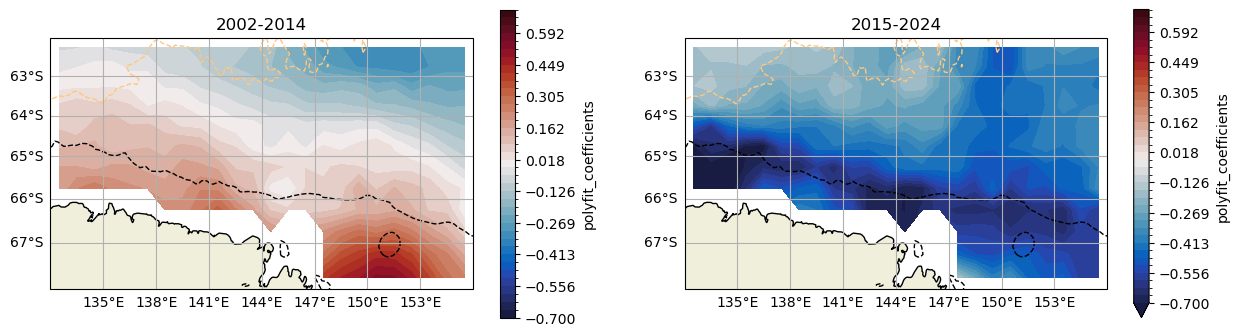

In [38]:
fig,axs = plt.subplots(1,2,figsize=(15,4),subplot_kw={'projection':ccrs.Mercator()})

def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

da_pre = sha_ds_sla.sha.sel(time=slice(shelf_sha.time[0],pd.Timestamp(2014,12,1)))
da_pos = sha_ds_sla.sha.sel(time=slice(pd.Timestamp(2014,12,1),shelf_sha_tmean.time[-1]))
trend1 = get_trend(da_pre)
trend2 = get_trend(da_pos)

fns.plotc(ax=axs[0],da=trend1,title='2002-2014',extent=expanded_extent,vmin=-0.7,vmax=0.7)
fns.plotc(ax=axs[1],da=trend2,title='2015-2024',extent=expanded_extent,vmin=-0.7,vmax=0.7)


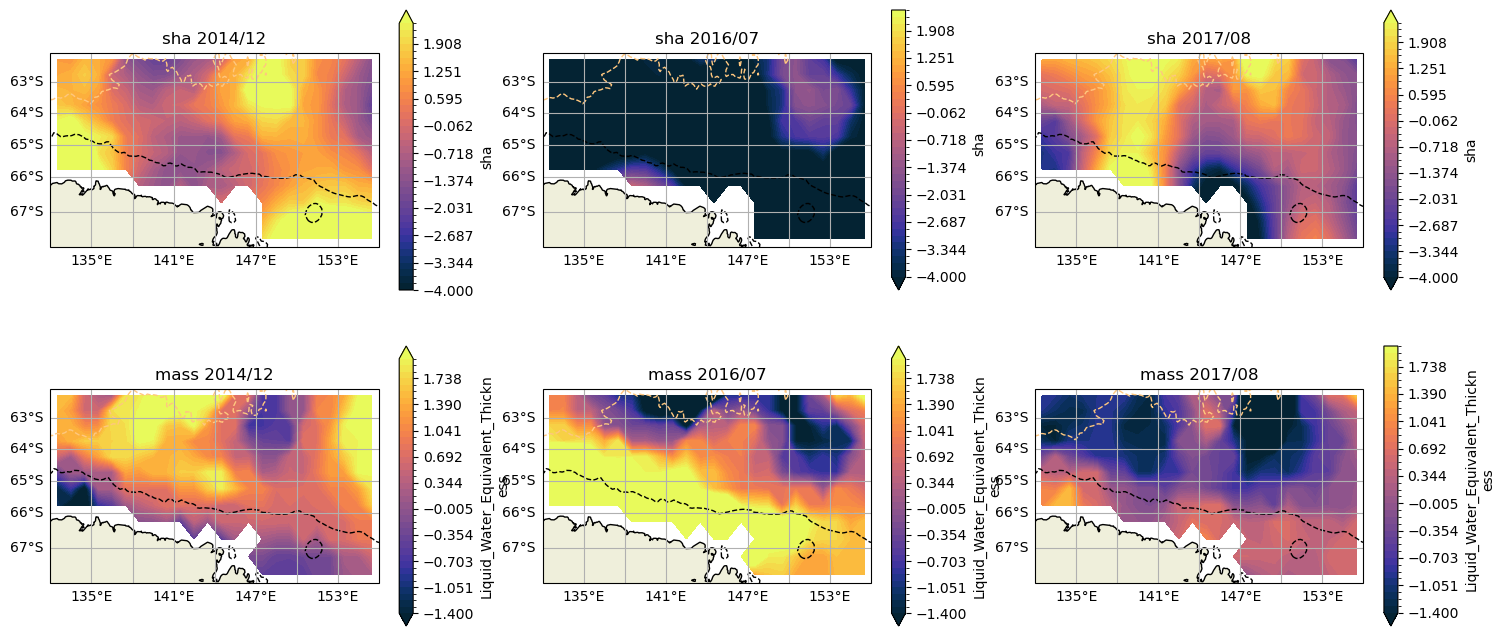

In [22]:
fig,axs2 = plt.subplots(2,3,figsize=(18,8),subplot_kw={'projection':ccrs.Mercator()})

def plot_sha(ax,t):
    fns.plotc(ax=ax,da=sha_ds_sla.sha.sel(time=t,method='nearest'),title='sha {}'.format(datetime.datetime.strftime(t, '%Y/%m')),extent=expanded_extent,cmap=cmocean.cm.thermal,vmin=-4,vmax=2.4) 

def plot_mass(ax,t):
    fns.plotc(ax=ax,da=sha_ds_sla.eha.sel(time=t,method='nearest'),title='mass {}'.format(datetime.datetime.strftime(t, '%Y/%m')),extent=expanded_extent,cmap=cmocean.cm.thermal,vmin=-1.4,vmax=2) 

axs=axs2[0]
plot_sha(axs[0],peak1)
plot_sha(axs[1],trgh1)
plot_sha(axs[2],peak2)

axs=axs2[1]
plot_mass(axs[0],peak1)
plot_mass(axs[1],trgh1)
plot_mass(axs[2],peak2)

ValueError: ('latitude', 'longitude') must be a permuted list of ('time', 'latitude', 'longitude'), unless `...` is included

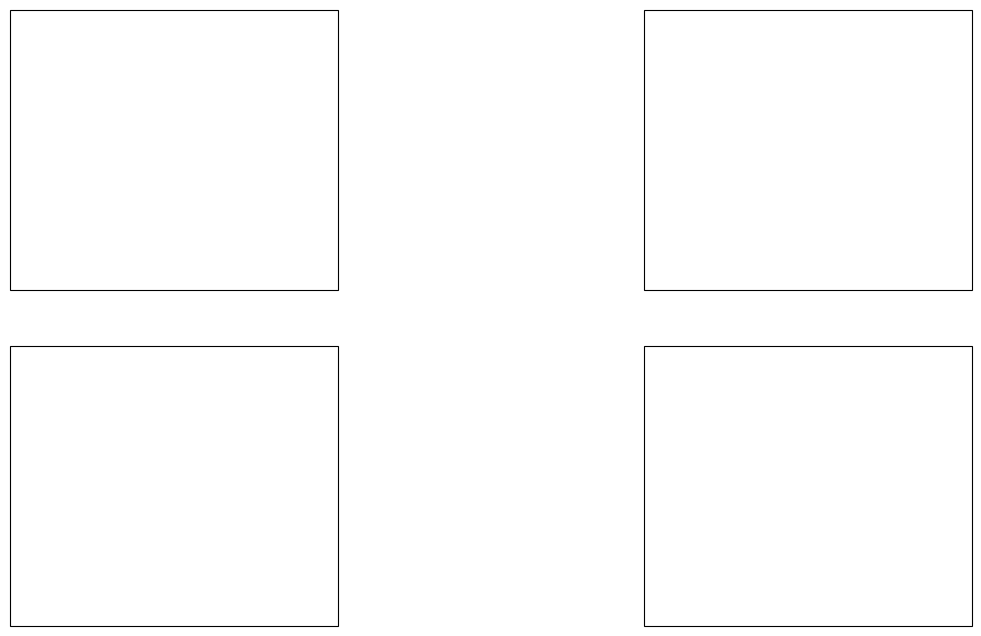

In [23]:
sha_pre2010 = sha_ds_sla.sha.sel(time=slice(shelf_sha.time[0],pd.Timestamp(2010,2,10)))
lwe_pre2010 = sha_ds_sla.eha.sel(time=slice(shelf_mass.time[0],pd.Timestamp(2010,2,10)))

#sha_2010_2016 = sha_

sha_pos2010 = sha_ds_sla.sha.sel(time=slice(pd.Timestamp(2010,3,1),shelf_sha.time[-1]))
lwe_pos2010 = sha_ds_sla.sel(time=slice(pd.Timestamp(2010,3,1),shelf_mass.time[-1]))

fig,axs = plt.subplots(2,2,figsize=(15,8),subplot_kw={'projection':ccrs.Mercator()})

axs=axs2[0]
fns.plotc(ax=axs[0],da=sha_pre2010,title='sha pre-2010',extent=expanded_extent,cmap=cmocean.cm.thermal,vmin=-3,vmax=2.4)
fns.plotc(ax=axs[1],da=c,title='sha may average',extent=expanded_extent,cmap=cmocean.cm.thermal,vmin=-3,vmax=2.4)



In [ ]:
cdict[np.int64(2002)] = [0.09019608, 0.74509804, 0.81176471, 1.        ]
cdict[np.int64(2003)] = [0.61960784, 0.85490196, 0.89803922, 1.        ]
cdict[np.int64(2005)] = [0.85882353, 0.85882353, 0.55294118, 1.        ]


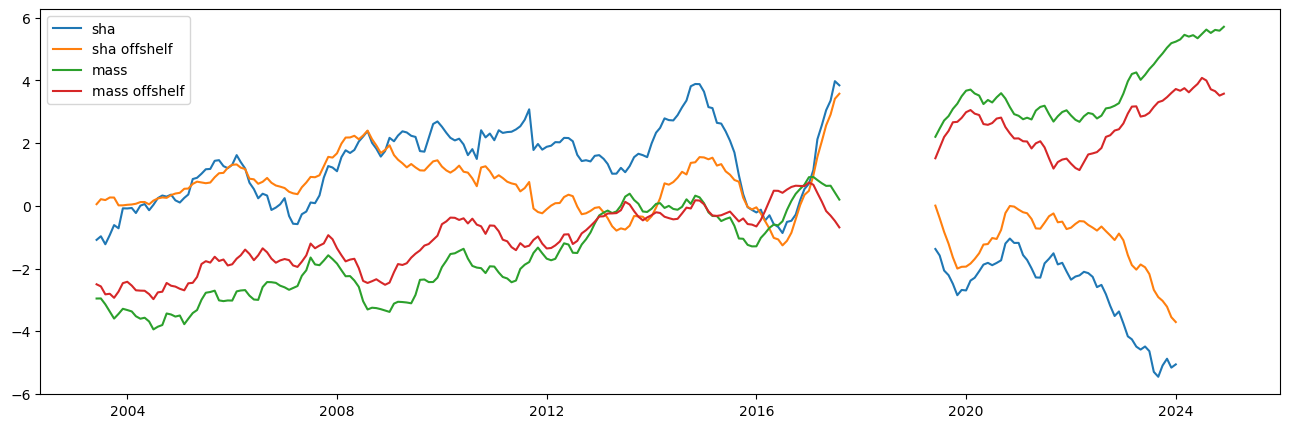

In [ ]:
fig,ax = plt.subplots(figsize=(16,5))
ax.plot(shelf_sha.time,shelf_sha.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='sha')
ax.plot(shelf_sha.time,offshelf_sha.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='sha offshelf')
ax.plot(shelf_mass.time,shelf_mass.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='mass')
ax.plot(shelf_mass.time,offshelf_mass.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='mass offshelf')
ax.legend()

ValueError: x and y can be no greater than 2D, but have shapes (12,) and (12, 12, 24)

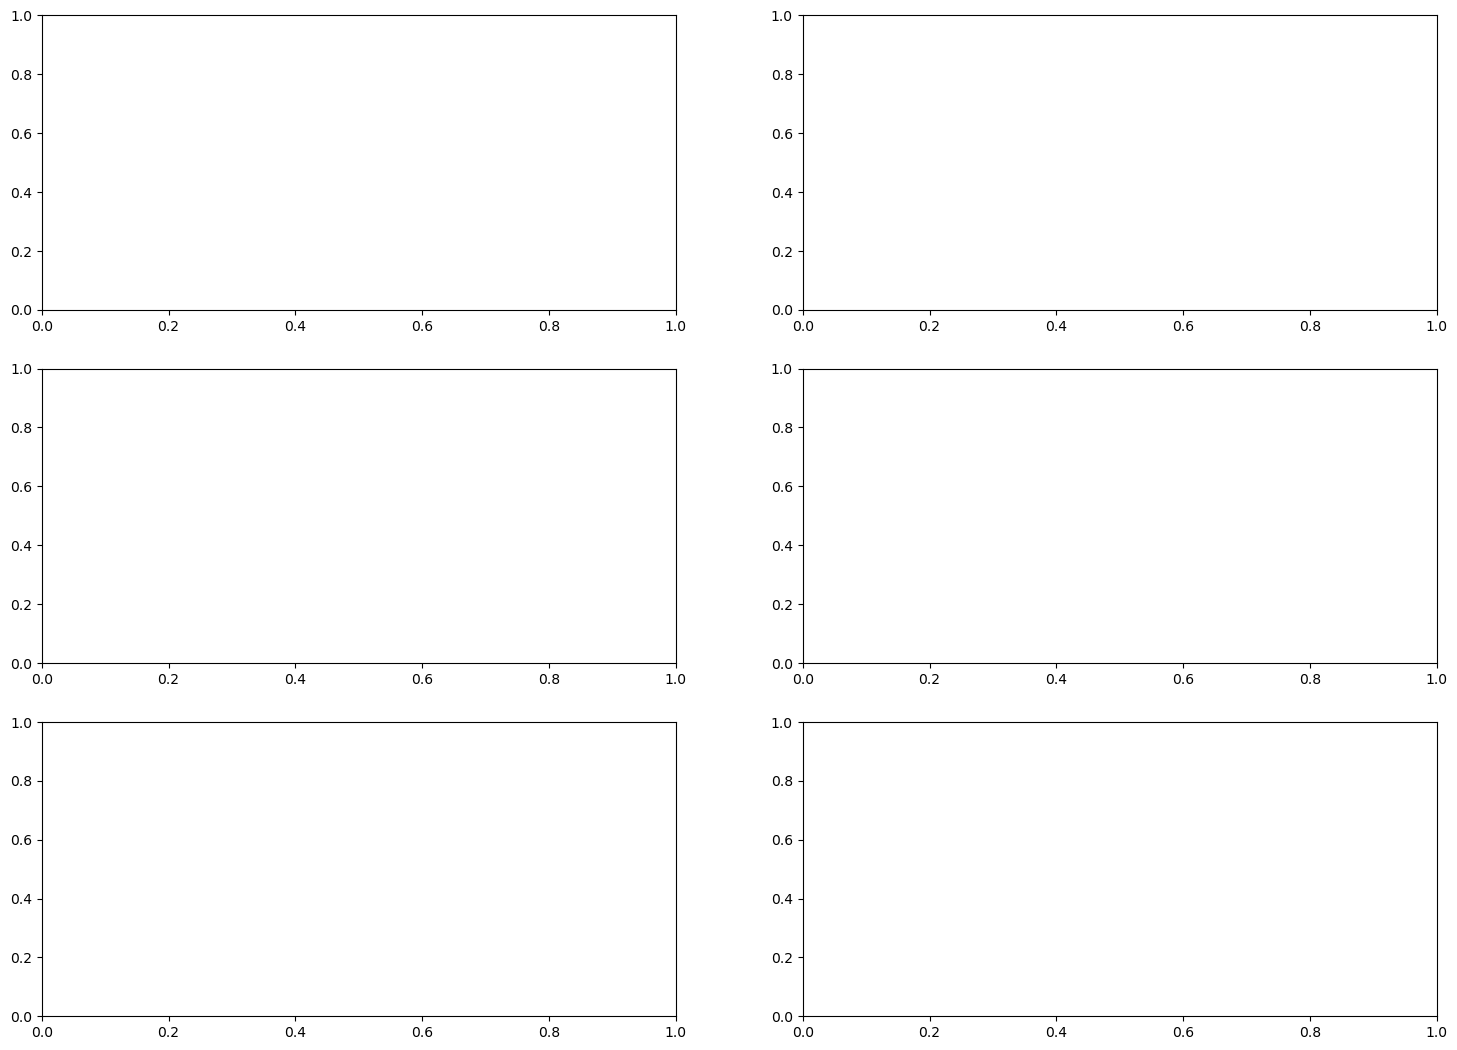

In [ ]:
# mnothly variability plot
fig,axs = plt.subplots(3,2,figsize=(18,13))

ax=axs[0] # CLIMATOLOGY sha
bx=axs[1] # CLIMATOLOGY mass
cx=axs[2] # timeseries

sha_pre2010['year'] = sha_pre2010.time.dt.year
sha_pos2010['year'] = sha_pos2010.time.dt.year
for y in np.unique(sha_pre2010.year):
    data = sha_pre2010.where(sha_pre2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    ax[0].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

for y in np.unique(sha_pos2010.year):
    data = sha_pos2010.where(sha_pos2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    ax[1].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

lwe_pre2010['year'] = lwe_pre2010.time.dt.year
lwe_pos2010['year'] = lwe_pos2010.time.dt.year
for y in np.unique(sha_pre2010.year):
    data = lwe_pre2010.where(sha_pre2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    bx[0].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

for y in np.unique(lwe_pos2010.year):
    data = lwe_pos2010.where(sha_pos2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    bx[1].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

ax[0].set_title('SHA Climatology Pre-2010')
ax[1].set_title('SHA Climatology Post-2010')
bx[0].set_title('MASS Climatology Pre-2010')
bx[1].set_title('MASS Climatology Post-2010')

ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
bx[0].grid(alpha=0.3)
bx[1].grid(alpha=0.3)

ax[0].set_xticks(np.arange(1,13),labels=month_labels)
ax[0].set_ylabel('SHA')
ax[0].set_xlabel(None)
ax[0].set_ylim([-10,10])
ax[1].set_ylim([-10,10])

bx[0].set_xticks(np.arange(1,13),labels=month_labels)
bx[0].set_ylabel('MASS')
bx[0].set_xlabel(None)
bx[0].set_ylim([-10,10])
bx[1].set_ylim([-10,10])
 
seasons_pre = fns.season_split(sha_pre2010)
seasons_pos = fns.season_split(sha_pos2010)

offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
scolor = {'summer':'hotpink','autumn':'brown','winter':'skyblue','spring':'limegreen'}

for s in seasons_pre.keys():
    data = seasons_pre[s].groupby('time.year').mean()
    cx[0].plot(data.year+offset[s],data,marker='x',linestyle='-',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)

    data = seasons_pos[s].groupby('time.year').mean()
    cx[1].plot(data.year+offset[s],data,marker='x',linestyle='-',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)

sha_pre2010['month'] = sha_pre2010.time.dt.month
sha_pos2010['month'] = sha_pos2010.time.dt.month
lwe_pre2010['month'] = lwe_pre2010.time.dt.month
lwe_pos2010['month'] = lwe_pos2010.time.dt.month


sns.lineplot(
    data=sha_pre2010.to_dataframe(),
    x="month", y="shaa", ax=ax[0], label='SHA'
)
sns.lineplot(
    data=sha_pos2010.to_dataframe(),
    x="month", y="shaa", ax=ax[1], label='SHA'
)
sns.lineplot(
    data=lwe_pre2010.to_dataframe(),
    x="month", y="eha", ax=bx[0], label='MASS'
)
sns.lineplot(
    data=lwe_pos2010.to_dataframe(),
    x="month", y="eha", ax=bx[1], label='MASS'
)


cx[0].set_title('SHA timeseries by season pre-2020')
cx[1].set_title('SHA timeseries by season Post-2010')

cx[0].legend(loc='best')
cx[1].legend(loc='best')

cx[0].grid(alpha=0.3)
cx[1].grid(alpha=0.3)

cx[0].set_ylim([-8,8])
cx[0].set_ylim([-8,8])



plt.tight_layout()



In [ ]:
n_min = 10

ds_zz_ons = ds_z_ons.mean('pres')
ds_zz_ofs = ds_z_ofs.mean('pres')

mon_mean__ons = ds_zz_ons.resample({'time':'MS'}).mean(skipna=True)
mon_std__ons = ds_zz_ons.resample({'time':'MS'}).std(skipna=True)
mon_count_ons = ds_zz_ons.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean_ons = mon_mean__ons.where(mon_count_ons > n_min, drop=True)
mon_std_ons = mon_std__ons.where(mon_count_ons > n_min, drop=True)

mon_mean__ofs = ds_zz_ofs.resample({'time':'MS'}).mean(skipna=True)
mon_std__ofs = ds_zz_ofs.resample({'time':'MS'}).std()
mon_count_ofs = ds_zz_ofs.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean_ofs = mon_mean__ofs.where(mon_count_ofs > n_min, drop=True)
mon_std_ofs = mon_std__ofs.where(mon_count_ofs > n_min, drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [ ]:
cli_count_ons = mon_mean_ons.groupby('time.month').count()

cli_mean_ons = mon_mean_ons.groupby('time.month').mean()
cli_std_ons = mon_mean_ons.groupby('time.month').std()

cli_mean_ons = cli_mean_ons.where(cli_count_ons.temp > 1,drop=True)
cli_std_ons = cli_std_ons.where(cli_count_ons.temp >1,drop=True)

cli_count_ofs = mon_mean_ofs.groupby('time.month').count()

cli_mean_ofs = mon_mean_ofs.groupby('time.month').mean()
cli_std_ofs = mon_mean_ofs.groupby('time.month').std()

cli_mean_ofs = cli_mean_ofs.where(cli_count_ofs.temp > 1,drop=True)
cli_std_ofs = cli_std_ofs.where(cli_count_ofs.temp >1,drop=True)



/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/

In [ ]:
df_ons=mon_mean_ons.groupby('time.month').where(cli_count_ons.temp > 1).to_dataframe()
df_ofs=mon_mean_ofs.groupby('time.month').where(cli_count_ofs.temp > 1).to_dataframe()


In [ ]:
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
month_values = xr.DataArray(np.arange(1,13),coords={'month':np.arange(1,13)})

In [ ]:
dfonshelf = ds_z_ons.drop_dims('pres').drop_vars(['mld']).to_dataframe()
dfonshelf['season'] = [fns.get_season(m) for m in dfonshelf.month]

dfoffshelf = ds_z_ofs.drop_dims('pres').drop_vars(['mld']).to_dataframe()
dfoffshelf['season'] = [fns.get_season(m) for m in dfoffshelf.month]

In [55]:
dfonshelf=dfonshelf.dropna()
dfonshelf['shaa']=dfonshelf.sha_interp - dfonshelf.sha_interp.mean()
dfonshelf['gpha']=dfonshelf.gph - dfonshelf.gph.mean()

dfoffshelf=dfoffshelf.dropna()
dfoffshelf['shaa']=dfoffshelf.sha_interp - dfoffshelf.sha_interp.mean()
dfoffshelf['gpha']=dfoffshelf.gph - dfoffshelf.gph.mean()


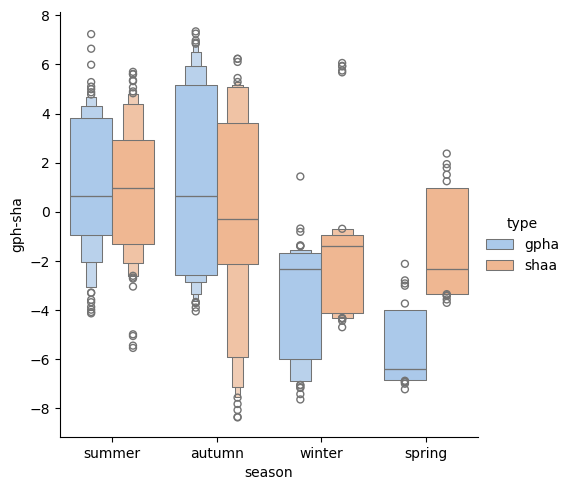

In [62]:
dfsns=dfonshelf.reset_index().melt(
    value_vars=['gpha', 'shaa'],
    var_name='type',
    value_name='gph-sha',
    id_vars=['season']
)

sns.catplot(data=dfsns,x='season',y='gph-sha',hue='type',order=['summer','autumn','winter','spring'],kind='boxen',palette='pastel')

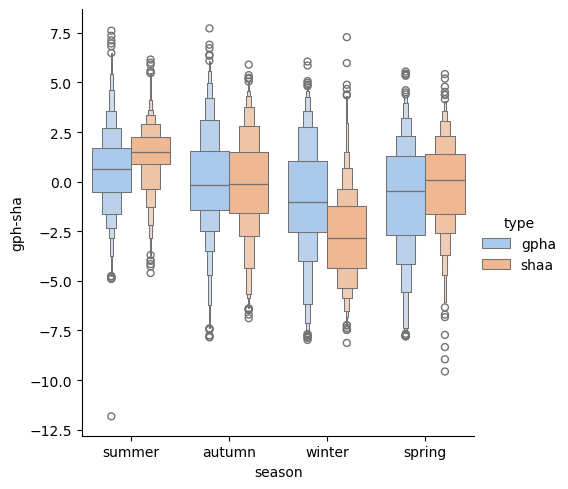

In [63]:
dfsns=dfoffshelf.reset_index().melt(
    value_vars=['gpha', 'shaa'],
    var_name='type',
    value_name='gph-sha',
    id_vars=['season']
)

sns.catplot(data=dfsns,x='season',y='gph-sha',hue='type',order=['summer','autumn','winter','spring'],kind='boxen',palette='pastel')

In [23]:
def yearly_climatology(ax,y,datamean,datastd):
    data = datamean.where(datamean.year==y,drop=True)
    dats = datastd.where(datamean.year==y,drop=True)

    if not len(data.time) == 0:
        clim = data.groupby('time.month').mean().broadcast_like(month_values)
        clis = dats.groupby('time.month').mean().broadcast_like(month_values)

        ax.errorbar(clim.month,clim.gph,yerr=clis.gph,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

def histogram(bx,y,mon_count,mon_mean_,bottom):
    year_count = mon_count.temp.where(mon_mean_.year==y,drop=True)
    if len(year_count) > 0:
        year_count = np.nan_to_num(year_count.groupby('time.month').mean().broadcast_like(month_values))
        if len(bx.containers) > 0:
            bx.bar(month_values, year_count, bottom = bottom,color=cdict[y],label=str(y))
            bottom = bottom + year_count
        else:
            bx.bar(month_values, year_count,color=cdict[y],label=str(y))
            bottom = year_count.copy()
    return bottom

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on

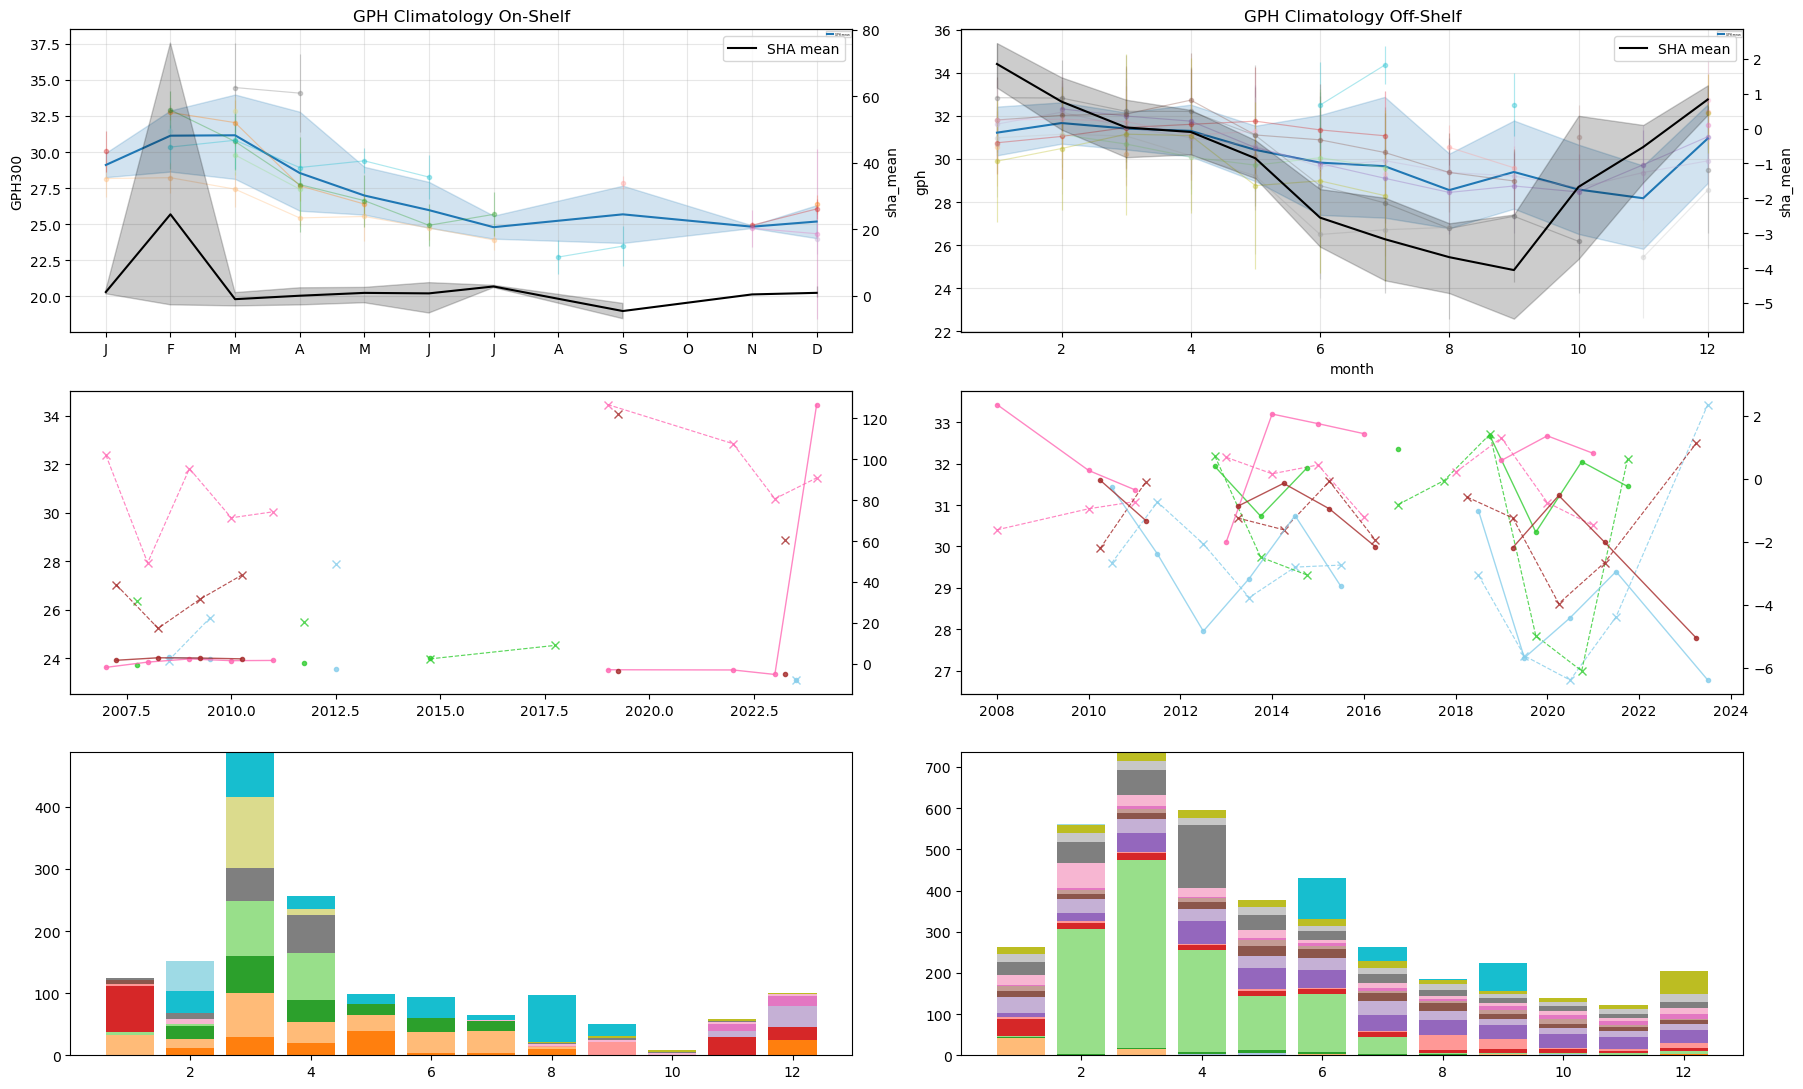

In [20]:
# mnothly variability plot
fig,axs = plt.subplots(3,2,figsize=(18,11))

ax=axs[0]
cx=axs[1]
bx=axs[2]

bot0 = None
bot1 = None

for y in [int(k) for k in cdict.keys()]:
    yearly_climatology(ax[0],y,mon_mean_ons,mon_std_ons)
    yearly_climatology(ax[1],y,mon_mean_ofs,mon_std_ofs)

    bot0=histogram(bx[0],y,mon_count_ons,mon_mean__ons,bot0)
    bot1=histogram(bx[1],y,mon_count_ofs,mon_mean__ofs,bot1)
    

seasons_ons = fns.season_split(mon_mean_ons)
seasons_ofs = fns.season_split(mon_mean_ofs)

offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
scolor = {'summer':'hotpink','autumn':'brown','winter':'skyblue','spring':'limegreen'}

shax0=cx[0].twinx()
shax1=cx[1].twinx()
for s in seasons_ons.keys():
    data = seasons_ons[s].groupby('time.year').mean()
    cx[0].plot(data.year+offset[s],data.gph,marker='x',linestyle='--',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)
    shax0.plot(data.year+offset[s],data.sha_mean,marker='.',linestyle='-',alpha=0.8,linewidth=1,c=scolor[s],label=s)

    data = seasons_ofs[s].groupby('time.year').mean()
    cx[1].plot(data.year+offset[s],data.gph,marker='x',linestyle='--',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)
    shax1.plot(data.year+offset[s],data.sha_mean,marker='.',linestyle='-',alpha=0.8,linewidth=1,c=scolor[s],label=s)


sns.lineplot(
    data=df_ons,
    x="month", y="gph", errorbar=("pi",90), ax=ax[0], label='GPH mean'
)
sns.lineplot(
    data=df_ons,
    x="month", y="sha_mean", ax=ax[0].twinx(), label='SHA mean', color='k'
)
sns.lineplot(
    data=df_ofs,
    x="month", y="gph", errorbar=("pi",90), ax=ax[1], label='GPH mean'
)
sns.lineplot(
    data=df_ofs,
    x="month", y="sha_mean", ax=ax[1].twinx(), label='SHA mean', color='k'

)

ax[0].set_title('GPH Climatology On-Shelf')
ax[1].set_title('GPH Climatology Off-Shelf')

ax[0].legend(loc='best',fontsize=2)
ax[1].legend(loc='best',fontsize=2)


ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)

ax[0].set_xticks(np.arange(1,13),labels=month_labels)
ax[0].set_ylabel('GPH300')
ax[0].set_xlabel(None)


# cx.grid(alpha=0.3)
# cx.set_xticks(np.arange(1,13),labels=month_labels)
# cx.set_ylabel('Salinity')
# cx.set_xlabel(None)
# cx.legend()

plt.tight_layout()



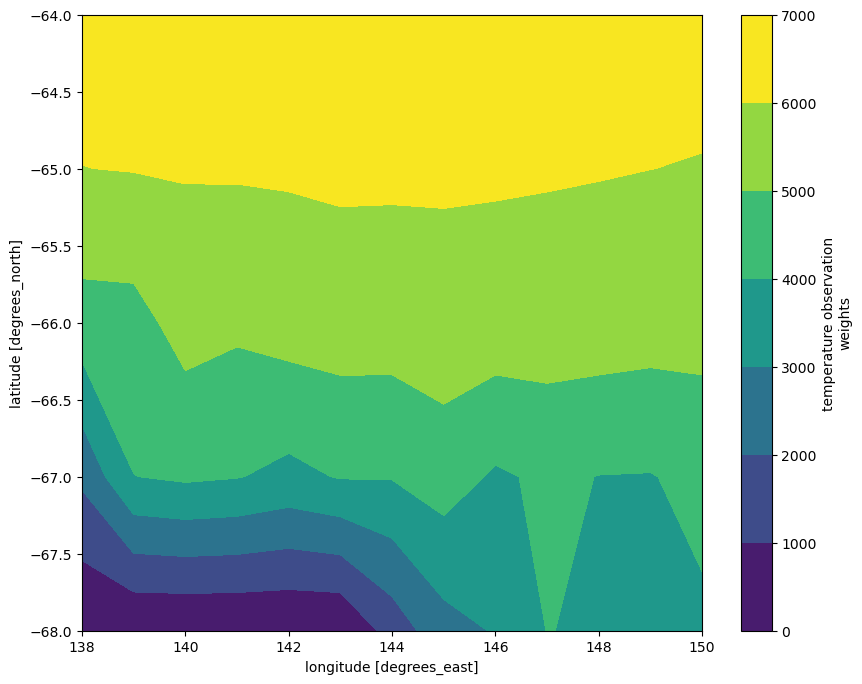

In [28]:
fig,ax = plt.subplots(figsize=(10,8))
en4.temperature_observation_weights.sum(['time','depth']).plot.contourf(ax=ax)


In [ ]:
en4

<xarray.Dataset> Size: 38MB
Dimensions:                          (depth: 42, lat: 5, lon: 13, time: 216,
                                      bnds: 2)
Coordinates:
  * depth                            (depth) float32 168B 5.022 ... 5.35e+03
  * lat                              (lat) float32 20B -68.0 -67.0 ... -64.0
  * lon                              (lon) float32 52B 138.0 139.0 ... 150.0
  * time                             (time) datetime64[ns] 2kB 2007-01-16T12:...
Dimensions without coordinates: bnds
Data variables: (12/15)
    temperature                      (time, depth, lat, lon) float64 5MB ...
    salinity                         (time, depth, lat, lon) float64 5MB ...
    temperature_uncertainty          (time, depth, lat, lon) float64 5MB ...
    salinity_uncertainty             (time, depth, lat, lon) float64 5MB ...
    temperature_observation_weights  (time, depth, lat, lon) float32 2MB nan ...
    salinity_observation_weights     (time, depth, lat, lon) float32 2MB ...
    ...                               ...
    year                             (time) int64 2kB 2007 2007 ... 2024 2024
    pres                             (depth) float64 336B nan nan ... nan nan
    asal                             (time, depth, lat, lon) float64 5MB nan ...
    ctemp                            (time, depth, lat, lon) float64 5MB nan ...
    rho                              (time, depth, lat, lon) float64 5MB nan ...
    gph                              (time, lat, lon) float64 112kB nan ... nan
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

In [ ]:
en4['pres']=gsw.conversions.p_from_z(en4.depth,en4.lat.mean())
en4['asal']=gsw.conversions.SA_from_SP(en4.salinity,en4.pres,en4.lon,en4.lat)
en4['ctemp']=gsw.conversions.CT_from_t(en4.asal,en4.temperature,en4.pres)
en4['rho']=gsw.density.rho(en4.asal,en4.ctemp,en4.pres)

# calculate specific volume for each profile/level
vs = (1/en4.rho - 1/gsw.density.rho(35,0,600))/9.82#ds[pres]))/9.82
vs = vs.assign_coords({'PRES_Pa': en4.pres*10000})

# integrate vs to get gpha for each profile
en4['gph'] = vs.groupby('time').map(lambda x: fns.integrate_na(x))

NameError: name 'en4' is not defined

/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks l

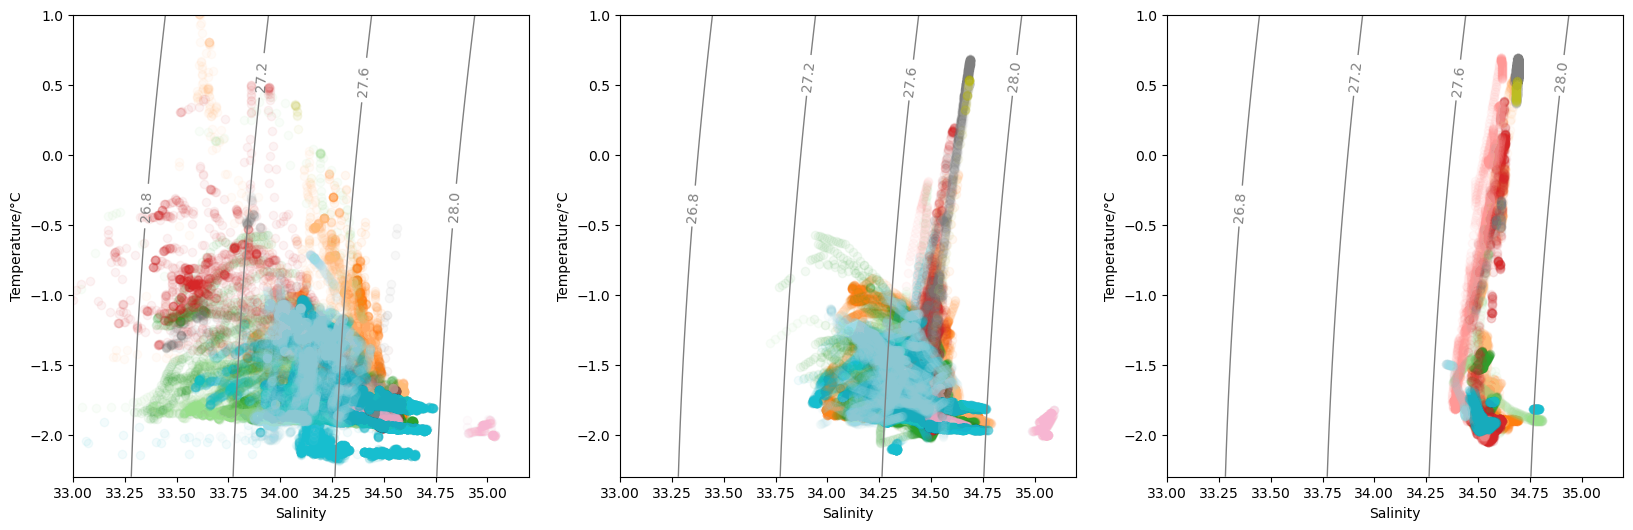

In [ ]:
# mnothly variability plot
fig,axs = plt.subplots(3,1,figsize=(10,11))
mon_year = mon_mean.groupby('time.year').mean()
moc_year = mon_count.where(mon_count.temp).groupby('time.year').count()


ax=axs[0]
cx=axs[1]
bx=axs[2]

for y_da in moc_year.year:
    y = y_da.item()
    data = mon_mean.where(mon_mean.year==y,drop=True)
    dats = mon_std.where(mon_mean.year==y,drop=True)

    if not len(data.time) ==0:
        clim = data.groupby('time.month').mean().broadcast_like(month_values)
        clis = dats.groupby('time.month').mean().broadcast_like(month_values)

        ax.errorbar(clim.month,clim.gph,yerr=clis.gph,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])
        
cx.scatter(mon_year.year,mon_year.gph,marker='x',alpha=0.8,linewidth=0.85,c=cshelf)

    # histogram
    # year_count = mon_count.temp.where(mon_mean_.year==y,drop=True)
    # if len(year_count) > 0:
    #     year_count = np.nan_to_num(year_count.groupby('time.month').mean().broadcast_like(month_values))
    #     if y > 2007:
    #         bx.bar(month_values, year_count, bottom = bottom,color=cdict[y],label=str(y))
    #         bottom = bottom + year_count
    #     else:
    #         bx.bar(month_values, year_count,color=cdict[y],label=str(y))
    #         bottom = year_count.copy()
        

ax.legend(loc='best',fontsize=2)
# bx.legend(ncol=7,fontsize='small')
# bx.set_ylabel('Number of Profiles')
# bx.set_xticks(np.arange(1,13),labels=month_labels)


sns.lineplot(
    data=df,
    x="month", y="gph", errorbar=("pi",90), ax=ax, 
)

        
# sns.lineplot(
#     data=df,
#     x="month", y="psal", errorbar=("pi",90), ax=cx
# )



ax.grid(alpha=0.3)
ax.set_xticks(np.arange(1,13),labels=month_labels)
ax.set_ylabel('GPH')
ax.set_xlabel(None)
ax.legend()

# cx.grid(alpha=0.3)
# cx.set_xticks(np.arange(1,13),labels=month_labels)
# cx.set_ylabel('Salinity')
# cx.set_xlabel(None)
# cx.legend()

plt.tight_layout()

